In [ ]:
'''LangGraph: Building resilient and stateful multi-actor applications with LLMs.'''

In [3]:
#EX01: Write a single node graph with a start and end endpoints _ LVL01

from typing import Dict, TypedDict, List # to organize the class and minimize bugs
from langgraph.graph import StateGraph # Framework that helps u design and manage the flow of tasks in ur app

In [9]:
# Now we create an agentState - The state that will be updated and passed thru nodes til the endpoint

class AgentState(TypedDict):
  values : List[int]
  name: str
  message: str

In [14]:


def process_vals(state: AgentState) -> AgentState:
  """Simple node that handles multiple differenr inputs"""

  state["message"] = state["name"] + ", you are doing great learning LangGraph. ue sum is " + str(sum(state['values']))
  return state



In [15]:
graph = StateGraph(AgentState)
graph.add_node("processor", process_vals)

graph.set_entry_point("processor")

app = graph.compile()

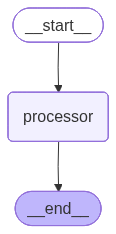

In [16]:
# Now we will visualize the graph for more clarity

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
# TESTING

result = app.invoke({"name": "Ala", "values": [23, 4, 23, 2, 0, 2]})
result["message"]


'Ala, you are doing great learning LangGraph. ue sum is 54'

In [18]:
print (result)

{'values': [23, 4, 23, 2, 0, 2], 'name': 'Ala', 'message': 'Ala, you are doing great learning LangGraph. ue sum is 54'}


EX02

In [22]:
from typing import Dict, List, TypedDict
from langgraph.graph import StateGraph
import math


In [35]:
class StateAgent2(TypedDict):
  name: str
  operation: str
  message: str
  values: List[int]

In [36]:
def processor(state: StateAgent2) -> StateAgent2:
  """Simple node that handles multiple differenr inputs"""
  x= sum(list(state["values"])) if state["operation"]=="+"  else math.prod(list(state["values"]))
  state["message"] = "Hi " + state["name"] + ", you're answer is: " + str(x)
  return state

In [37]:
graph2 = StateGraph(StateAgent2)
graph2.add_node("proc", processor)

graph2.set_entry_point("proc")
app2 = graph2.compile()


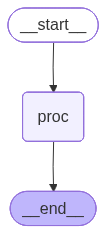

In [38]:
# Now we will visualize the graph for more clarity

from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [41]:
results = app2.invoke({"name": "Ala", "operation": "*", "values": [23, 4, 23, 2, 0, 2]})
results


{'name': 'Ala',
 'operation': '*',
 'message': "Hi Ala, you're answer is: 0",
 'values': [23, 4, 23, 2, 0, 2]}

EX03

In [48]:
class AgentStating(TypedDict):
  name: str
  age: int
  skills: List[str]
  final: str


In [56]:
def node01(state: AgentStating) -> AgentStating:
  """first node in the sequence"""
  state["final"] = f"Hi {state["name"]}"
  return state

def node02(state: AgentStating) -> AgentStating:
  """second node in the sequence"""
  state["final"] = state["final"] + f", you are {state["age"]} years old"
  return state

def node03(state : AgentStating) -> AgentStating:
  """Third node in the sequence"""
  state["final"] += " and you are greate at "
  state["final"] += " , ".join(list(state["skills"]))
  return state



In [57]:
graph3= StateGraph(AgentStating)
graph3.add_node("node01", node01)
graph3.add_node("node02", node02)
graph3.add_node("node03", node03)


#SET ENTRY POINT
graph3.set_entry_point("node01")

#SET AN EDGES
graph3.add_edge("node01", "node02")
graph3.add_edge("node02", "node03")



app3 = graph3.compile()

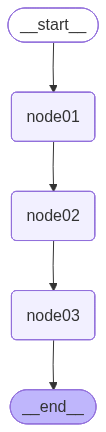

In [58]:

from IPython.display import Image, display
display(Image(app3.get_graph().draw_mermaid_png()))

In [59]:
results = app3.invoke({"name": "Ala", "age": 34, "skills": ["coding", "dancing", "cooking muffins"]})
results

{'name': 'Ala',
 'age': 34,
 'skills': ['coding', 'dancing', 'cooking muffins'],
 'final': 'Hi Ala, you are 34 years old and you are greate at coding , dancing , cooking muffins'}

EX4


In [93]:
from langgraph.graph import StateGraph, START, END

In [94]:
class AgentStarter(TypedDict):
  n1: int
  n2: int
  op: str
  answer: str
  sign: str


In [95]:
def addition(state: AgentStarter) -> AgentStarter:
  """This node will perform simple addition in the graph"""

  state["answer"] = str(state["n1"] + state["n2"])
  return state

def substraction(state: AgentStarter) -> AgentStarter:
  """This node will perform simple substraction in the graph"""

  state["answer"] = str(state["n1"] - state["n2"])
  return state

def multiplication(state: AgentStarter) -> AgentStarter:
  """This node will perform simple multiplication in the graph"""

  state["answer"] = str(state["n1"] * state["n2"])
  return state

def division(state: AgentStarter) -> AgentStarter:
  """This node will perform simple division in the graph"""

  state["answer"] = str(state["n1"] / state["n2"])
  return state



In [96]:
def decider(state: AgentStarter) -> AgentStarter:
  """This node will decide the next node in the graph"""
  if state["op"] == "+":
    return "addition_operation"
  elif state["op"] == "-":
    return "substraction_operation"
  elif state["op"] == "*":
    return "multiplication_operation"
  elif state["op"] == "/":
    return "division_operation"
  else:
    raise ValueError(f"Invalid operation: {state['op']}")

In [84]:
graph = StateGraph(AgentStarter)

# A pass-through node that simply returns the current state
def pass_through(state: AgentStarter) -> AgentStarter:
    return state

#Graph Nodes : their names
graph.add_node("start_point", pass_through) # New entry point node
graph.add_node("addition_node", addition)
graph.add_node("substraction_node", substraction)
graph.add_node("multiplication_node", multiplication)
graph.add_node("division_node", division)

#SET ENTRY POINTS
graph.set_entry_point("start_point") # Set the new pass_through node as the entry point

#SET EDGES
# START implicitly connects to the entry point, no explicit edge needed
graph.add_conditional_edges(
    "start_point", # Conditional edges now originate from the pass_through node
    decider,       # The decider function is used as the condition for routing
    {
        "addition_operation": "addition_node",
        "substraction_operation": "substraction_node",
        "multiplication_operation": "multiplication_node",
        "division_operation": "division_node"
    }
)

graph.add_edge("addition_node", END)
graph.add_edge("substraction_node", END)
graph.add_edge("multiplication_node", END)
graph.add_edge("division_node", END)

app = graph.compile()

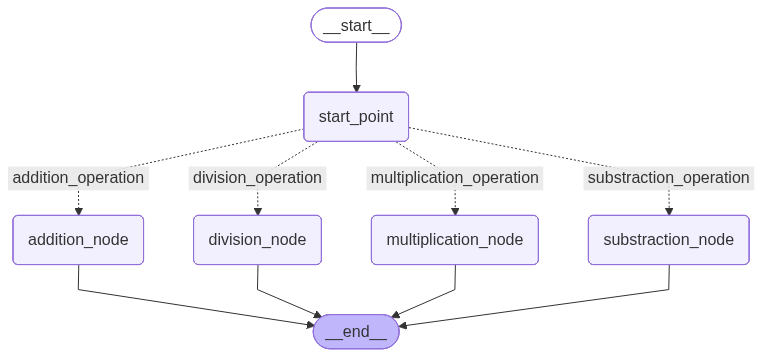

In [78]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [79]:
initial_state = {"n1": 10, "n2": 5, "op": "+"}
results = app.invoke(initial_state)
results

{'n1': 10, 'n2': 5, 'op': '+', 'answer': '15'}

EX05: Multiple conditioned routers

In [97]:
#SAME AS THE LAST EXERCISE WITH THIS END

def decider2(state: AgentStarter) -> AgentStarter:
  """This node will decide the next node in the graph"""
  if not state["answer"]:
    return "error: The first router did not get an answer!"
  else:
    if state["answe"]> 0:
      return "positive"
    else:
      return "negative"

In [98]:
def positive_node(state: AgentStarter) -> AgentStarter:
  """This node will decide the next node in the graph"""
  state["sign"] = "positive"
  return state

def negative_node(state: AgentStarter) -> AgentStarter:
  """This node will decide the next node in the graph"""
  state["sign"] = "negative"
  return state



In [99]:
graph = StateGraph(AgentStarter)

# A pass-through node that simply returns the current state
def pass_through(state: AgentStarter) -> AgentStarter:
    return state

#Graph Nodes : their names
graph.add_node("router1", pass_through) # New entry point node
graph.add_node("addition_node", addition)
graph.add_node("substraction_node", substraction)
graph.add_node("multiplication_node", multiplication)
graph.add_node("division_node", division)
graph.add_node("router2", pass_through) # New entry point node
graph.add_node("positive_node", positive_node)
graph.add_node("negative_node", negative_node)



#SET ENTRY POINTS
graph.set_entry_point("router1") # Set the new pass_through node as the entry point

#SET EDGES
# START implicitly connects to the entry point, no explicit edge needed
graph.add_conditional_edges(
    "router1", # Conditional edges now originate from the pass_through node
    decider,       # The decider function is used as the condition for routing
    {
        "addition_operation": "addition_node",
        "substraction_operation": "substraction_node",
        "multiplication_operation": "multiplication_node",
        "division_operation": "division_node"
    }
)
graph.add_conditional_edges(
    "router2", # Conditional edges now originate from the pass_through node
    decider2,       # The decider function is used as the condition for routing
    {
        "positive": "positive_node",
        "negative": "negative_node"
    }
)

graph.add_edge("addition_node","router2")
graph.add_edge("substraction_node","router2")
graph.add_edge("multiplication_node","router2")
graph.add_edge("division_node","router2")




graph.add_edge("positive_node", END)
graph.add_edge("negative_node", END)


app = graph.compile()

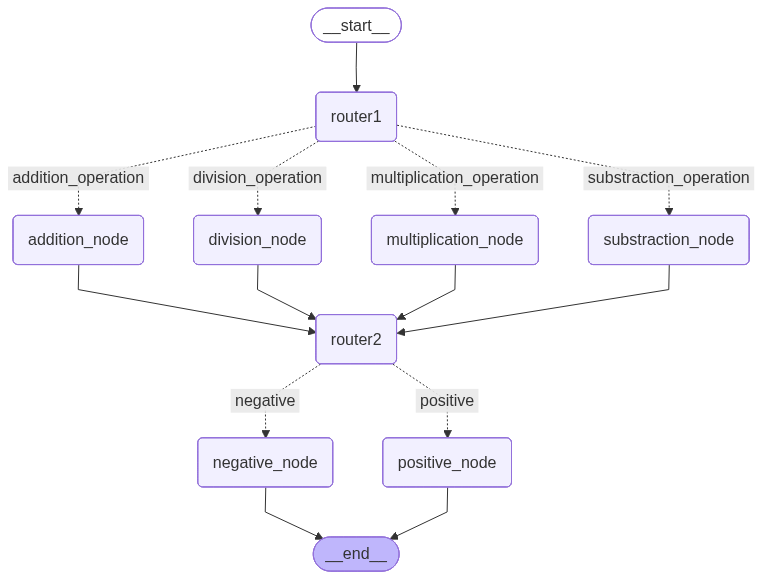

In [100]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))